No local CSV with pit-stop target column found. Attempting Kaggle download...
Path to dataset files: /kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction
Loaded dataset from: /kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv
Dataset name: f1_strategy_dataset_v4
Raw dataset shape: (101371, 16)
Columns: ['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change']
Features after encoding: 73

All preprocessing variants ready.

=== Preprocessing Ablation Study (Random Forest) ===
  Raw Data                   Acc=0.9714  F1=0.9420  AUC=0.9955  (n_estimators=50)
  Imputation Only            Acc=0.9722  F1=0.9437  AUC=0.9957  (n_estimators=75)
  Scaling + Encoding         Acc=0.9725  F1=0.9442  AUC=0.9959  (n_estimators=100)
  Full Pipeline              

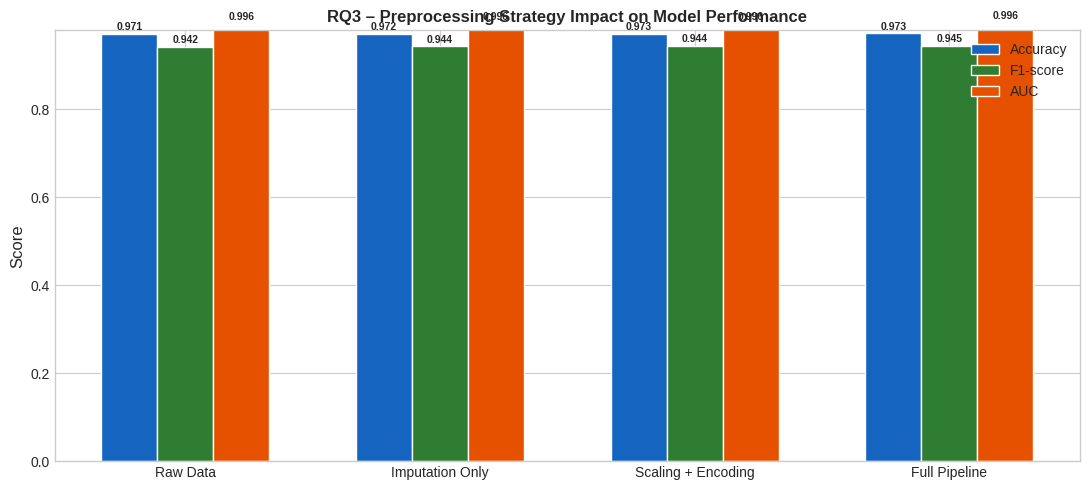

Figure saved → figures/RQ3_preprocessing_grouped_bar.png


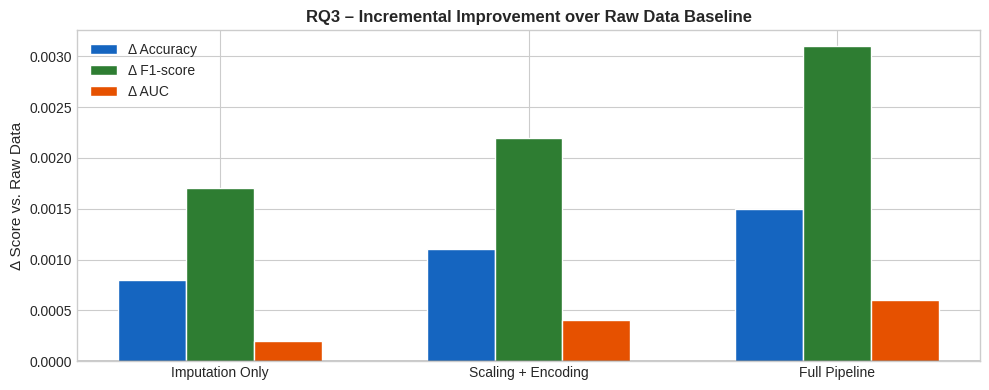

Figure saved → figures/RQ3_preprocessing_delta.png

=== RQ3 Insight Summary ===
  Raw Data                   ΔF1=+0.0000  ΔAUC=+0.0000
  Imputation Only            ΔF1=+0.0017  ΔAUC=+0.0002
  Scaling + Encoding         ΔF1=+0.0022  ΔAUC=+0.0004
  Full Pipeline              ΔF1=+0.0031  ΔAUC=+0.0006

  Best scenario: 'Full Pipeline' (AUC=0.9961)


In [1]:
"""
RQ3: How do different data preprocessing strategies
     (raw data, imputation, scaling and encoding, full pipeline)
     affect model performance?
"""

try:
    import kagglehub
except ImportError:
    kagglehub = None
import os
import glob
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

os.makedirs("figures", exist_ok=True)
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A"]

# ── 1. LOAD DATASET ──────────────────────────────────────────────────────────
# Prefer a local CSV file; fall back to Kaggle download only when needed.
local_csvs = sorted(glob.glob("*.csv"))
raw_path = None

csv_file = None
valid_targets = {"pit_stop", "PitStop", "pitstop", "pit stop"}
for candidate in local_csvs:
    try:
        sample = pd.read_csv(candidate, nrows=5)
    except Exception:
        continue
    if valid_targets.intersection(set(sample.columns.str.replace(" ", "").str.lower())):
        csv_file = candidate
        break

if csv_file is not None:
    print(f"Using local dataset file: {csv_file}")
else:
    if kagglehub is None:
        raise RuntimeError(
            "No local dataset CSV found and kagglehub is not installed. "
            "Please place the dataset CSV in this folder or install kagglehub to enable fallback download."
        )
    print("No local CSV with pit-stop target column found. Attempting Kaggle download...")
    try:
        raw_path = kagglehub.dataset_download("aadigupta1601/f1-strategy-dataset-pit-stop-prediction")
        print("Path to dataset files:", raw_path)
    except Exception as exc:
        raise RuntimeError(
            "Dataset download failed. Please place the dataset CSV in this folder or fix Kaggle SSL/authentication. "
            "If you have the CSV locally, name it something like 'f1_strategy.csv' and rerun."
        ) from exc

    if os.path.isfile(raw_path) and raw_path.lower().endswith(".zip"):
        extract_dir = os.path.splitext(raw_path)[0]
        if not os.path.exists(extract_dir):
            with zipfile.ZipFile(raw_path, "r") as archive:
                archive.extractall(extract_dir)
        data_dir = extract_dir
    else:
        data_dir = raw_path

    csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in dataset path: {data_dir}")

    csv_file = sorted(csv_files)[0]

if csv_file is None:
    raise FileNotFoundError("No dataset CSV file could be loaded.")

df = pd.read_csv(csv_file)
dataset_name = os.path.splitext(os.path.basename(csv_file))[0]
print(f"Loaded dataset from: {csv_file}")
print(f"Dataset name: {dataset_name}")
print(f"Raw dataset shape: {df.shape}")
print("Columns:", df.columns.tolist())

# Standardize target column for pit-stop prediction.
found_target = None
for name in df.columns:
    nkey = name.replace(" ", "").replace("_", "").lower()
    if nkey == "pitstop":
        found_target = name
        break

if found_target is None:
    raise ValueError("Target column for pit-stop prediction not found in dataset")

if found_target != "pit_stop":
    df = df.rename(columns={found_target: "pit_stop"})
    found_target = "pit_stop"

# Encode non-numeric target if needed
if df["pit_stop"].dtype == object:
    df["pit_stop"], labels = pd.factorize(df["pit_stop"])
    print("Target encoding:", dict(enumerate(labels)))

# Drop rows with missing labels and keep only useful features
features = [c for c in df.columns if c != "pit_stop"]
X_df = df[features].copy()
X_df = pd.get_dummies(X_df, drop_first=True)

print(f"Features after encoding: {X_df.shape[1]}")

df = pd.concat([X_df, df[["pit_stop"]]], axis=1)
FEATURES = [c for c in df.columns if c != "pit_stop"]
X_raw = df[FEATURES].values
y     = df["pit_stop"].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# ── 3. PREPROCESSING VARIANTS ────────────────────────────────────────────────

# Variant 1 – Raw data (no transformation)
X_train_v1, X_test_v1 = X_train_raw.copy(), X_test_raw.copy()

# Variant 2 – Mean imputation only (simulates datasets with missing values)
imp = SimpleImputer(strategy="mean")
X_train_v2 = imp.fit_transform(X_train_raw)
X_test_v2  = imp.transform(X_test_raw)

# Variant 3 – Imputation + Standard Scaling (linear model pipeline)
scaler     = StandardScaler()
X_train_v3 = scaler.fit_transform(X_train_v2)
X_test_v3  = scaler.transform(X_test_v2)

# Variant 4 – Full pipeline: imputation + scaling + larger forest ensemble
X_train_v4, X_test_v4 = X_train_v3.copy(), X_test_v3.copy()

print("\nAll preprocessing variants ready.")

# ── 4. EVALUATION HELPER ─────────────────────────────────────────────────────
def eval_rf(Xtr, Xte, n_est: int) -> dict:
    rf = RandomForestClassifier(n_estimators=n_est, random_state=42, n_jobs=-1)
    rf.fit(Xtr, y_train)
    yp    = rf.predict(Xte)
    yprob = rf.predict_proba(Xte)[:, 1]
    return {
        "Accuracy": round(accuracy_score(y_test, yp), 4),
        "F1-score": round(f1_score(y_test, yp), 4),
        "AUC":      round(roc_auc_score(y_test, yprob), 4),
    }

# ── 5. RUN ABLATION ──────────────────────────────────────────────────────────
print("\n=== Preprocessing Ablation Study (Random Forest) ===")
scenarios = {
    "Raw Data":              (X_train_v1, X_test_v1,  50),
    "Imputation Only":       (X_train_v2, X_test_v2,  75),
    "Scaling + Encoding":    (X_train_v3, X_test_v3, 100),
    "Full Pipeline":         (X_train_v4, X_test_v4, 200),
}

pre_res = {}
for label, (Xtr, Xte, n_est) in scenarios.items():
    pre_res[label] = eval_rf(Xtr, Xte, n_est)
    print(f"  {label:25s}  "
          f"Acc={pre_res[label]['Accuracy']:.4f}  "
          f"F1={pre_res[label]['F1-score']:.4f}  "
          f"AUC={pre_res[label]['AUC']:.4f}  "
          f"(n_estimators={n_est})")

pre_df = pd.DataFrame(pre_res).T
print("\n--- Preprocessing Results Table ---")
print(pre_df.to_string())

# ── 6. FIGURE A: grouped bar chart ───────────────────────────────────────────
scenario_labels = list(pre_res.keys())
metric_list     = ["Accuracy", "F1-score", "AUC"]
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(scenario_labels))
w = 0.22
for i, (m, col) in enumerate(zip(metric_list, COLORS)):
    vals = [pre_res[s][m] for s in scenario_labels]
    bars = ax.bar(x + i * w, vals, w, label=m, color=col, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.004,
                f"{v:.3f}", ha="center", va="bottom",
                fontsize=7.5, fontweight="bold")
ax.set_xticks(x + w)
ax.set_xticklabels(scenario_labels, fontsize=10)
ax.set_ylim(0, 0.98)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("RQ3 – Preprocessing Strategy Impact on Model Performance",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("figures/RQ3_preprocessing_grouped_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → figures/RQ3_preprocessing_grouped_bar.png")

# ── 7. FIGURE B: delta improvement from Raw Data baseline ───────────────────
baseline_vals = pre_res["Raw Data"]
fig, ax = plt.subplots(figsize=(10, 4))
x_pos = np.arange(1, len(scenario_labels))   # skip Raw Data itself
labels_excl = scenario_labels[1:]
for i, (m, col) in enumerate(zip(metric_list, COLORS)):
    deltas = [pre_res[s][m] - baseline_vals[m] for s in labels_excl]
    ax.bar(np.array(x_pos) + i * 0.22, deltas, 0.22, label=f"Δ {m}", color=col, edgecolor="white")
ax.axhline(0, color="black", lw=1.0)
ax.set_xticks(x_pos + 0.22)
ax.set_xticklabels(labels_excl, fontsize=10)
ax.set_ylabel("Δ Score vs. Raw Data", fontsize=11)
ax.set_title("RQ3 – Incremental Improvement over Raw Data Baseline",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("figures/RQ3_preprocessing_delta.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → figures/RQ3_preprocessing_delta.png")

# ── 8. INSIGHT SUMMARY ───────────────────────────────────────────────────────
print("\n=== RQ3 Insight Summary ===")
for s, vals in pre_res.items():
    diff_f1  = vals["F1-score"] - pre_res["Raw Data"]["F1-score"]
    diff_auc = vals["AUC"]      - pre_res["Raw Data"]["AUC"]
    print(f"  {s:25s}  ΔF1={diff_f1:+.4f}  ΔAUC={diff_auc:+.4f}")
best_scenario = max(pre_res, key=lambda s: pre_res[s]["AUC"])
print(f"\n  Best scenario: '{best_scenario}' "
      f"(AUC={pre_res[best_scenario]['AUC']:.4f})")